# Q9.
```{admonition}
:class: note
This exercise involves the `Auto` data set. Make sure the missing values have been removed from the data.

In [1]:
import pandas as pd
Auto = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Auto.csv',na_values=['?'])

In [2]:
Auto = Auto.dropna()

## (a)
```{admonition}
:class: note
Which of the predictors are quantitative, and which are qualitative?

In [3]:
Auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
year              int64
origin            int64
name                str
dtype: object

In [4]:
Auto.sample(4)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
168,23.0,4,140.0,83.0,2639,17.0,75,1,ford pinto
164,21.0,6,231.0,110.0,3039,15.0,75,1,buick skyhawk
121,15.0,8,318.0,150.0,3399,11.0,73,1,dodge dart custom
343,39.1,4,79.0,58.0,1755,16.9,81,3,toyota starlet


In [5]:
Auto['cylinders'].unique()

array([8, 4, 6, 3, 5])

| Quantitative | Qualitative |
|--------------|-------------|
| mpg          | name
| displacement | year
| horsepower   | origin
| weight       | 
| acceleration |
| cylinders    |

Cylinders are from small set -- could be moved to qualitative

Year corresponds to model year

Origin corresponds to country

## (b)
```{admonition}
:class: note
What is the *range* of each quantitative predictor?

In [6]:
quant_vars = ['mpg','displacement','horsepower','weight','acceleration','cylinders']
pd.DataFrame({'Range':Auto[quant_vars].max() - Auto[quant_vars].min()}).transpose()

,mpg,displacement,horsepower,weight,acceleration,cylinders
Range,37.6,387.0,184.0,3527.0,16.8,5.0


## (c)
```{admonition}
:class: note
What is the mean and standard deviation of each quantitative predictor?

In [7]:
Auto_StdMean = pd.DataFrame({'Standard Deviation':Auto[quant_vars].std(),'Mean':Auto[quant_vars].mean()})
Auto_StdMean.transpose()

,mpg,displacement,horsepower,weight,acceleration,cylinders
Standard Deviation,7.805007,104.644004,38.491160,849.402560,2.758864,1.705783
Mean,23.445918,194.411990,104.469388,2977.584184,15.541327,5.471939


## (d)
```{admonition}
:class: note
Now remove the 10th through 85th observations. What is the range, mean, and standard deviation of each predictor in the subset of the data that remains?

In [8]:
Auto_middle_missing = pd.concat([Auto.iloc[:9],Auto.iloc[84:]])
Auto_middle_missing

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [9]:
pd.DataFrame({'Range':Auto_middle_missing[quant_vars].max() - Auto_middle_missing[quant_vars].min(), 'Standard Deviation':Auto_middle_missing[quant_vars].std(),'Mean':Auto_middle_missing[quant_vars].mean()}).transpose()

,mpg,displacement,horsepower,weight,acceleration,cylinders
Range,35.600000,387.000000,184.000000,3348.000000,16.300000,5.000000
Standard Deviation,7.880898,99.939488,35.895567,812.649629,2.693813,1.658135
Mean,24.368454,187.753943,100.955836,2939.643533,15.718297,5.381703


## (e)
```{admonition}
:class: note
Using the full data set, investigate the predictors graphically, using scatterplots or other tools of your choice. Create some plots highlighting the relationships among the predictors.

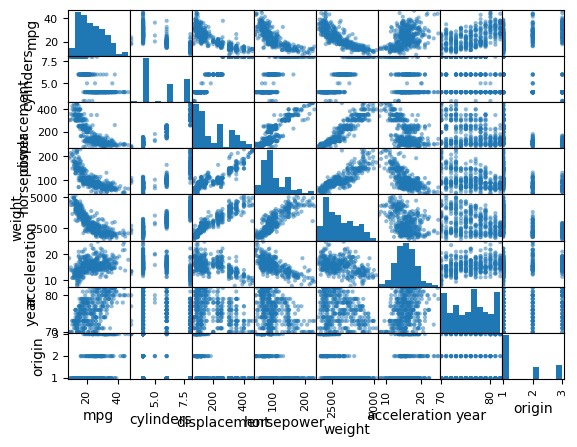

In [10]:
pd.plotting.scatter_matrix(Auto) ;

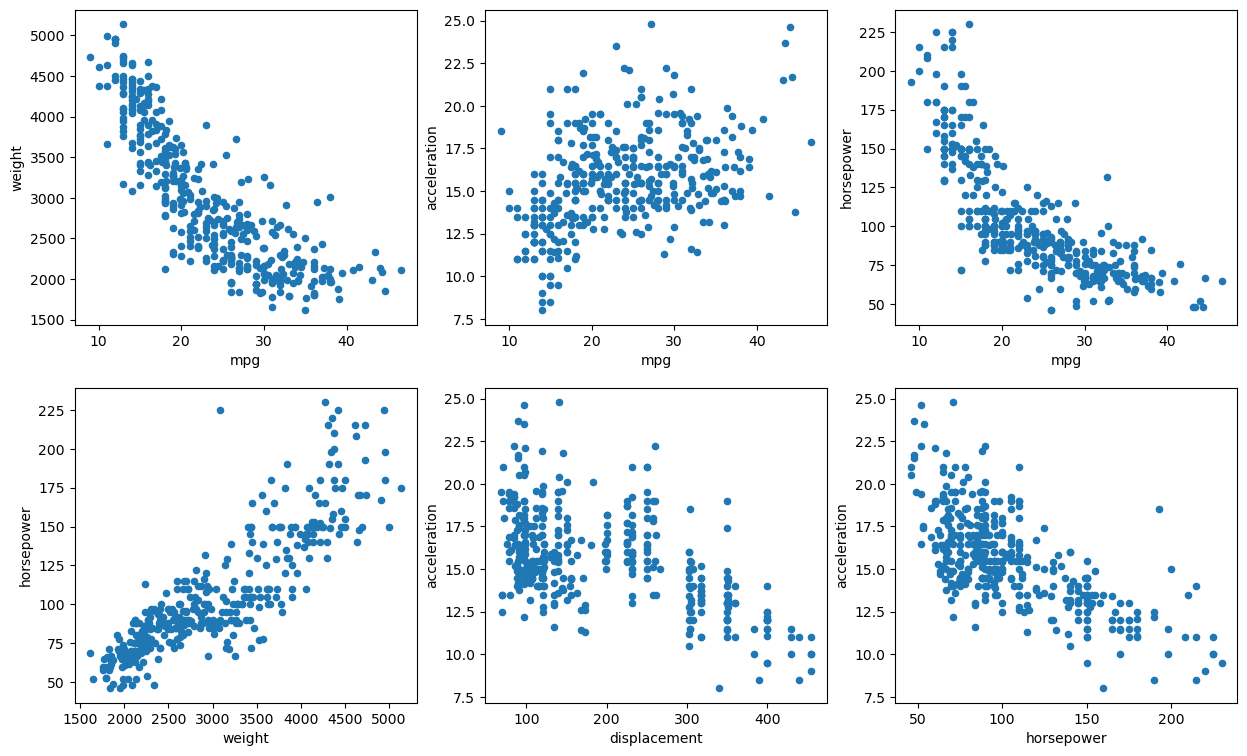

In [11]:
import matplotlib as plt
fig,ax = plt.pyplot.subplots(2,3,figsize=(15,9))

Auto.plot.scatter('mpg','weight',ax = ax[0][0])
Auto.plot.scatter('mpg','acceleration',ax = ax[0][1])
Auto.plot.scatter('mpg','horsepower',ax = ax[0][2])
Auto.plot.scatter('weight','horsepower',ax = ax[1][0])
Auto.plot.scatter('displacement','acceleration',ax = ax[1][1])
Auto.plot.scatter('horsepower','acceleration',ax = ax[1][2]);

In [12]:
pd.Series(Auto['cylinders'], dtype='category')

0      8
1      8
2      8
3      8
4      8
      ..
392    4
393    4
394    4
395    4
396    4
Name: cylinders, Length: 392, dtype: category
Categories (5, int64): [3, 4, 5, 6, 8]

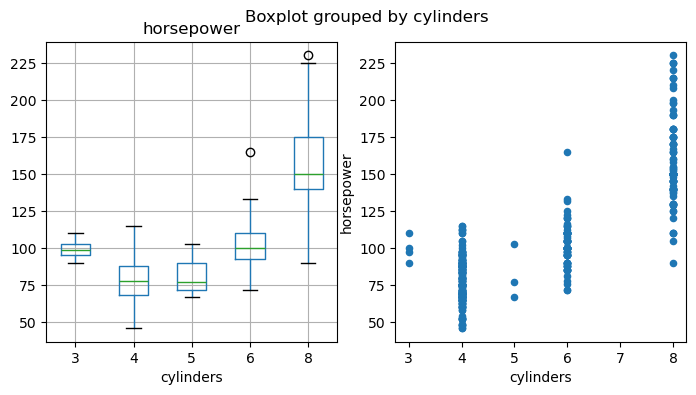

In [13]:
fig,ax = plt.pyplot.subplots(1,2,figsize=(8,4))
ax.flatten()
Auto.boxplot(column = 'horsepower',by='cylinders',ax = ax[0])
Auto.plot.scatter('cylinders','horsepower',ax = ax[1]) ;

## (f)
```{admonition}
:class: note
Suppose that we wish to predict gas mileage (`mpg`) on the basis of the other variables. Do your plots suggest that any of the other variables might be useful in predicting `mpg`?

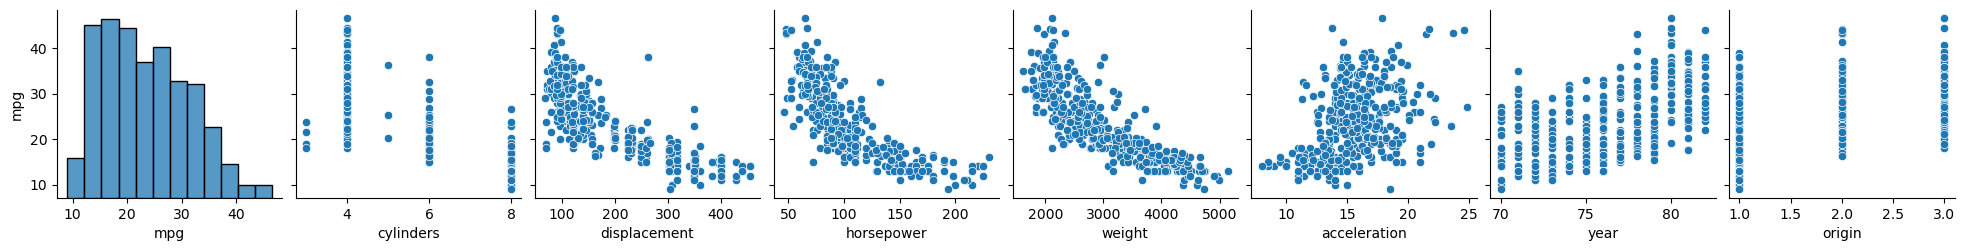

In [14]:
import seaborn as sns
sns.pairplot(Auto,y_vars = 'mpg') ;

The predictors `displacement`, `horsepower`, and `weight` all appear to have a quadratic relationship with `mpg`. There seems to be a possibly minor linear relation between `mpg` and `year` or `cylinders`.